# Sutherlands Law Exploration and Gas Properties
##### 11/25/2025
###### Hypersonic Nozzle - Senior Design Fall 2025 - Dr. Nicholaus Parziale
###### Lucas Brusa-O'Connell (lbrusaoc@stevens.edu)

- - -
Dependancies:
- numpy
- matplotlib
- scipy
- jupyter notebook
- CoolProp

In [2]:
import CoolProp.CoolProp as cp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import pint
ureg = pint.UnitRegistry()

Create State class to hold all the data of a thermodynamic state (Temperature, Pressure, Density, etc.)
Requires only two independent intensive properties to calculate all others.

In [3]:
class State:
    def __init__(self, fluid, **kwargs):
        """
        Initialize the thermodynamic state with exactly two properties.

        Parameters:
            fluid (str): The working fluid (e.g., 'Water', 'Air').
            kwargs: Thermodynamic properties as keyword arguments.
                Supported keys: 'T', 'P', 'H', 'S', 'Q', 'V'
                Example: T=300, P=101325
        """
        self.fluid = fluid
        self.properties = {
            "T": None,   # Temperature in K
            "P": None,   # Pressure in Pa
            "H": None,   # Mass Specific Enthalpy in J/kg
            "S": None,   # Mass Specific Entropy in J/kg.K
            "V": None,   # Dynamic Viscovity in Pa.s
            "D": None,   # Density in kg/m^3
            "Cpmass": None,         # Constant Pressure Specific Heat (mass based) in J/kg/K
            "Cvmass": None,         # Constant Volume Specific Heat (mass based) in J/kg/K
            "gas_constant": None,   # Molar Gas Constant in J/mol/K
            "molarmass": None,      # Molar Mass in kg/mol
            "Z": None,   #compressibility factor (dimensionless)
            "Prandtl": None,        # Prandtl number (dimensionless)
        }


        # Populate provided properties
        provided_properties = {k: v for k, v in kwargs.items() if k in self.properties}
        # Error handling to make sure every state is defined by at least 2 properties
        if len(provided_properties) != 2:
            raise ValueError("Exactly two properties must be provided to initialize the state.")

        self.properties.update(provided_properties)

        # Extract the provided property names and values
        (prop1_name, prop1_value), (prop2_name, prop2_value) = provided_properties.items()

        # Calculate missing properties
        self._calculate_properties(prop1_name, prop1_value, prop2_name, prop2_value)

        # Set class attributes for each property
        for prop, value in self.properties.items():
            setattr(self, prop, value)


    def _calculate_properties(self, prop1_name, prop1_value, prop2_name, prop2_value):
        """
        Calculate and fill in all missing thermodynamic properties using CoolProp.
        """
        # List of all properties for CoolProp
        property_keys = list(self.properties.keys())

        # Use CoolProp to calculate missing properties
        for prop in property_keys:
            if self.properties[prop] is None:
                try:
                    self.properties[prop] = cp.PropsSI(
                        prop, prop1_name, prop1_value, prop2_name, prop2_value, self.fluid
                    )
                except ValueError:
                    # Handle cases where the property cannot be calculated
                    #print("ur fucked")########################################################################################
                    self.properties[prop] = None


    def __repr__(self):
        """
        String representation of the thermodynamic state for print outs
        """
        return f"{self.properties}"
# End State class

#### Control Points

In [4]:
DataPoints = 600
P_He = 1.01325e5
T_low = 50
T_high = 600
T_avg = (T_high + T_low)/2
intervals = 12
fluid = 'Helium'

#### Reference for all other fluid properties necessary for Card 2 in Sivells Code
Turbulent boundary layer recovery factor is calculated via [NASA](https://ntrs.nasa.gov/api/citations/19930082751/downloads/19930082751.pdf)

In [ ]:
ref_State = State(fluid=fluid,T=T_avg,P=P_He) # reference state

gamma = ref_State.Cpmass/ref_State.Cvmass
print("Gamma (cp/cv)")
print(gamma) # unitless

R_gas = ref_State.gas_constant/ref_State.molarmass * ureg.J/ureg.kg/ureg.K
print("Gas Constant")
#print(R_gas)
#print(R_gas.to(ureg.ft*ureg.lbf/(ureg.slug*ureg.degR)))
print(R_gas.to(ureg.ft**2 /(ureg.s**2 * ureg.degR)))

Z_gas = ref_State.Z
print("Compressibility Factor")
print(Z_gas)

TBLRF = (ref_State.Prandtl)**(1/3) # Turbulent boundary layer recovery factor 
print("Turbulent boundary layer recovery factor")
print(TBLRF)

Gamma (cp/cv)
1.666549332667606
Gas Constant
2077.2636899696745 joule / kelvin / kilogram
12421.93348373192 foot ** 2 / degree_Rankine / second ** 2
Compressibility Factor
1.0004398554383873
Turbulent boundary layer recovery factor
0.8720755907632446


### Least-Squares Regression (LSR) of the Sutherlands law of two variables (b,S) onto the data provided by NIST through CoolProp.
Defines an operating pressure (may be innacurate due to varying pressure within the nozzle)
Defines an operating temperature range between T_low and T_high

The LSR, denoted as curve_fit, returns the two constant of Sutherlands law, b and S.
Constants are saved as b_He and S_He
[ANSYS](https://www.afs.enea.it/project/neptunius/docs/fluent/html/ug/node294.htm#eq-viscosity-suth2)

In [6]:
temps = np.linspace(T_low, T_high, num=DataPoints)
viscocities = [State(fluid=fluid,T=T1,P=P_He).V for T1 in temps]

# sutherlands law of viscocity curve fitting to NIST values
def sutherlands(T, b, S): # modified sutherlands used by sevills in his code (p.64)
    T = np.asarray(T)

    # allocate result array
    mu = np.zeros_like(T, dtype=float)

    # region T > S
    mask = T > S
    mu[mask] = b * (T[mask]**1.5) / (T[mask] + S)

    # region T <= S
    mu[~mask] = b * T[~mask] / (2 * np.sqrt(S))

    return mu
results = curve_fit(sutherlands, xdata = temps, ydata = viscocities)[0]
b_He,S_He = results[0], results[1]

# ensure proper unit conversion using pint library
# viscocity is 
#   - lbm / (ft * s)
#   - lbf * s / ft^2
#   - Pa * s
#   - N * s / m^2
#   - kg / (m * s)


#ureg.formatter.default_format = "~P"
b_unit_SI = (ureg.pascal * ureg.second / ureg.degK**0.5)                    #  Pa * s / K^1/2
b_unit_Imp = (ureg.lbf * ureg.second / (ureg.foot**2 * ureg.degR**0.5))     # lbf * s / (ft^2 * R^1/2)

# print("SI Units")
# print(f"b_He: {b_He * b_unit_SI}")
# print(f"S_He: {S_He * ureg.degK}")
# print("Imperial Units")
print(f"b_He: {(b_He * b_unit_SI).to(b_unit_Imp)}")
print(f"S_He: {(S_He * ureg.degK).to(ureg.degR)}")

b_He: 2.1697506078080686e-08 force_pound * second / degree_Rankine ** 0.5 / foot ** 2
S_He: 96.95644063015793 degree_Rankine


#### Create a percent error function to compare the sutherland fit against the NIST data

In [7]:
def percent_error(T):
    approx  = sutherlands(T,b_He,S_He)
    true    = cp.PropsSI('V', 'T', T, 'P', P_He, fluid)
    return 100 * (approx - true) / true

### Plot Nist curve and Sutherlands Curve

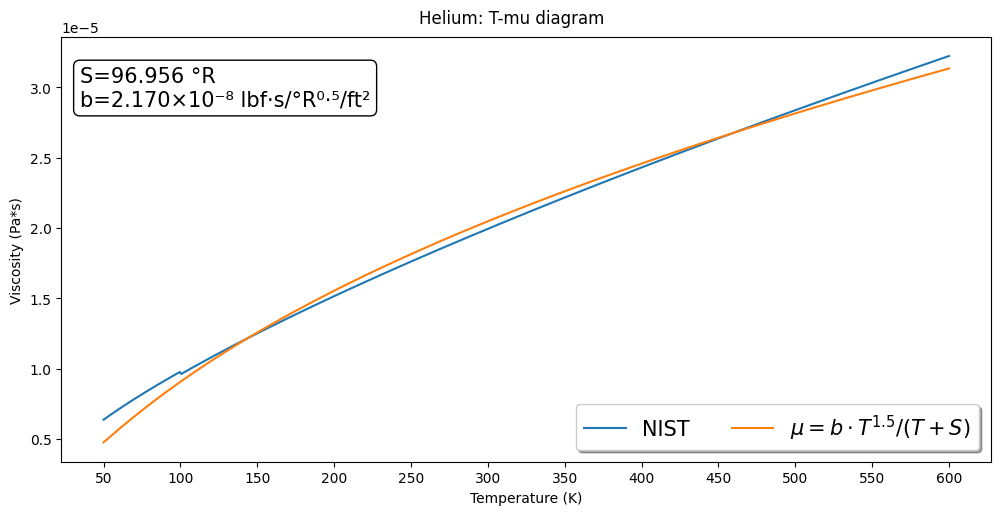

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(temps,
         viscocities,
         label="NIST")


ax1.plot(temps,
         sutherlands(temps, b_He, S_He),
         label=r'$\mu=b\cdot T^{1.5}/(T+S)$')

ax1.text(
    0.02,  # x-coordinate (fraction of axes width)
    0.93,  # y-coordinate (fraction of axes height)
    f'S={(S_He * ureg.degK).to(ureg.degR):~P.3f}\nb={(b_He * b_unit_SI).to(b_unit_Imp):~P.3e}',
    transform=ax1.transAxes,  # Use axes coordinates (0 to 1)
    horizontalalignment='left',
    verticalalignment='top',
    fontsize=15,
    bbox=dict(boxstyle='round', facecolor='white')
)

ax1.set_xticks(np.linspace(T_low, T_high, intervals))
ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel("Viscosity (Pa*s)")
fig.suptitle(f"{fluid}: T-mu diagram")

box = ax1.get_position()
lines1, labels1 = ax1.get_legend_handles_labels()
ax1.set_position([box.x0, box.y0 + box.height * 0.15,
                  box.width, box.height * 0.92])
ax1.legend(lines1, labels1, 
           loc='upper center', bbox_to_anchor=(0.77, 0.16),
           fancybox=True, shadow=True, ncol=2, fontsize=15)

plt.show()

#### Plot NIST+Sutherlands and overlay a % error line

max error: 25.35506041786133 %


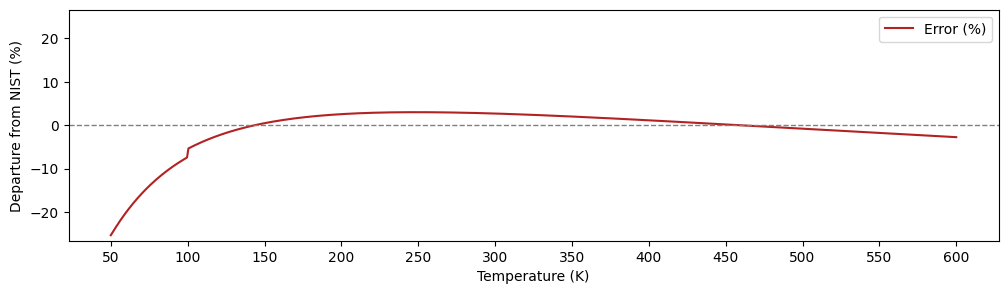

In [9]:
fig, ax = plt.subplots(figsize=(12, 3))

# --- Departure curve only ---
ax.plot(
    temps,
    percent_error(temps),     # this now represents signed % departure
    label="Error (%)",
    color='firebrick'
)

ax.set_xticks(np.linspace(T_low, T_high, intervals))
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Departure from NIST (%)")

# symmetric y-axis limits
max_abs_y = np.max(np.abs(percent_error(temps)))
ax.set_ylim(-max_abs_y-0.05*max_abs_y, max_abs_y+0.05*max_abs_y)
print(f"max error: {max_abs_y} %")
# zero horizontal line
ax.axhline(0, linestyle="--", linewidth=1, color="gray")


# Legend
ax.legend(loc="upper right")

plt.show()